In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
path_baseline = "../data/analytics/model_results/ITA-CJUS/con_exog/baseline/validation_metrics_all_steps_baseline.csv"
df_base_line = pd.read_csv(path_baseline)
df_base_line["model"] = df_base_line["model"].replace({"NaiveByLag": "Baseline"})
df_base_line.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,Baseline,4.172650,2.763117,17.411006,0.185292,0.308102,"{""1"": 0.30810213871434383}"
1,2,Baseline,4.885513,3.336726,23.868234,-0.116859,0.372063,"{""1"": 0.31222833805459754, ""2"": 0.432559624243..."
2,3,Baseline,5.318628,3.688850,28.287802,-0.323662,0.411326,"{""1"": 0.30621292680421924, ""2"": 0.446288169803..."
3,4,Baseline,5.634789,3.964383,31.750847,-0.485708,0.442050,"{""1"": 0.3010627578814067, ""2"": 0.3884005957231..."
4,5,Baseline,5.771485,4.162266,33.310038,-0.558666,0.464115,"{""1"": 0.31316464716179404, ""2"": 0.424767337897..."


In [3]:
path_lstm = "../data/analytics/model_results/ITA-CJUS/con_exog/lstm/validation_metrics_all_steps_direct.csv"
df_lstm = pd.read_csv(path_lstm)
df_lstm.head()


,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LSTM,2.706439,1.825429,7.324814,0.657252,0.203545,"{""1"": 0.20354493566903353}"
1,2,LSTM,4.943633,3.599089,24.439510,-0.143590,0.401317,"{""1"": 0.39690163947617646, ""2"": 0.405782121033..."
2,3,LSTM,3.524230,2.449671,12.420198,0.418826,0.273151,"{""1"": 0.2551106230869846, ""2"": 0.2839268731852..."
3,4,LSTM,3.465595,2.323489,12.010352,0.438003,0.259081,"{""1"": 0.213153607025839, ""2"": 0.22643658634854..."
4,5,LSTM,3.542049,2.550222,12.546110,0.412934,0.284363,"{""1"": 0.2559445583785007, ""2"": 0.2645411364022..."


In [4]:
path_direct = "../data/analytics/model_results/ITA-CJUS/con_exog/direct/validation_metrics_all_steps_direct.csv"
df_direct = pd.read_csv(path_direct)
df_direct["model"] = df_direct["model"].replace(
    {"LGBM": "LGBM direct", "XGBoost": "XGBoost direct"}
)
df_direct.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LGBM direct,3.026764,1.970716,9.161298,0.571318,0.219745,"{""1"": 0.21974523313518213}"
1,1,LGBM direct,3.026764,1.970716,9.161298,0.571318,0.219745,"{""1"": 0.21974523313518213}"
2,1,XGBoost direct,3.283559,2.177991,10.781762,0.495492,0.242858,"{""1"": 0.24285751287625862}"
3,1,XGBoost direct,3.283559,2.177991,10.781762,0.495492,0.242858,"{""1"": 0.24285751287625862}"
4,2,LGBM direct,3.189894,2.103103,10.175423,0.523865,0.234507,"{""1"": 0.22044724463042542, ""2"": 0.248722669479..."


In [5]:
path_simple = "../data/analytics/model_results/ITA-CJUS/con_exog/validation_metrics_all_steps_direct.csv"
df = pd.read_csv(path_simple)
df["model"] = df["model"].replace(
    {"LGBM": "LGBM recursive", "XGBoost": "XGBoost recursive"}
)


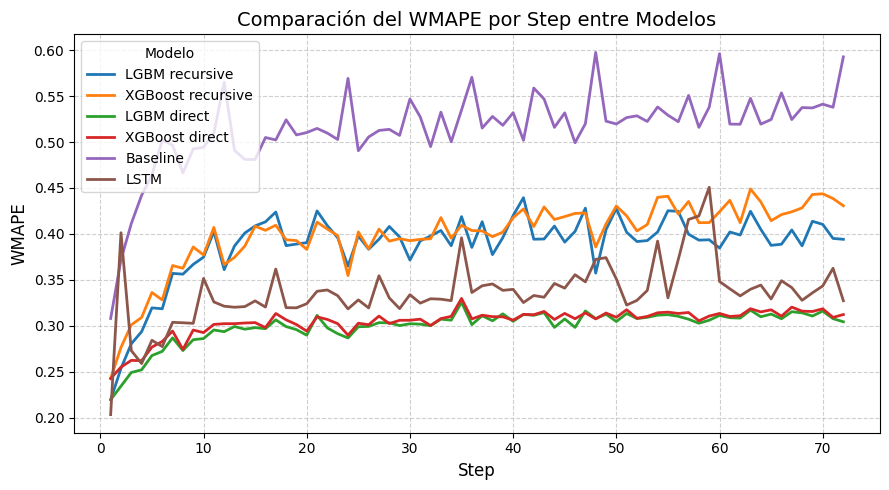

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Supongamos que ya tienes los dos DataFrames: df y df_base_line ---
# df contiene LGBM y XGBoost
# df_base_line contiene Baseline

# Si quieres verificar que ambos tienen las mismas columnas:
# print(df.columns)
# print(df_base_line.columns)

# --- Unir los dos DataFrames ---
df_all = pd.concat([df, df_direct, df_base_line, df_lstm], ignore_index=True)

# --- Graficar las tres líneas ---
plt.figure(figsize=(9, 5))

for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.plot(subset["step"], subset["wmape"], marker="", linewidth=2, label=model)

# --- Personalizar ---
plt.title("Comparación del WMAPE por Step entre Modelos", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("WMAPE", fontsize=12)
plt.legend(title="Modelo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


In [6]:
# --- Graficar las tres líneas ---
plt.figure(figsize=(9, 5))

for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.plot(subset["step"], subset["rmse"], marker="o", linewidth=2, label=model)

# --- Personalizar ---
plt.title("Comparación del RMSE por Step entre Modelos", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("WMAPE", fontsize=12)
plt.legend(title="Modelo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


NameError: name 'df_all' is not defined

<Figure size 900x500 with 0 Axes>